In [1]:
import sqlite3
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
SQLITE_PATH = "/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/db.sqlite"
NEWS_ARTICLES_TABLE = "modified_articles"
CHUNK_WORDS = 300


In [4]:
conn = sqlite3.connect(SQLITE_PATH)
cursor = conn.cursor()

In [5]:

df = pd.read_sql_query(f'SELECT * FROM "{NEWS_ARTICLES_TABLE}"', conn)
non_tech_df = df.copy()

# Vader sentiment

In [7]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


sia = SentimentIntensityAnalyzer()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.6 MB/s eta 0:00:00


In [8]:
def vader_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return "neutral"
    # Chunk and average
    words = text.split()
    chunks = [" ".join(words[i:i+CHUNK_WORDS]) for i in range(0, len(words), CHUNK_WORDS)]
    scores = [sia.polarity_scores(chunk)["compound"] for chunk in chunks]
    score = np.mean(scores)
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [9]:
non_tech_df["combined_text"] = (
	df["title"].fillna("") + " " +
	df["text"].fillna("")
).str.strip()

In [10]:
non_tech_df["vader_sentiment"] = non_tech_df["combined_text"].apply(vader_sentiment)



VADER sentiment distribution:
vader_sentiment
positive    9493
negative     741
neutral      223
Name: count, dtype: int64


,vader_sentiment,count,percent
0,positive,9493,90.78
1,negative,741,7.09
2,neutral,223,2.13


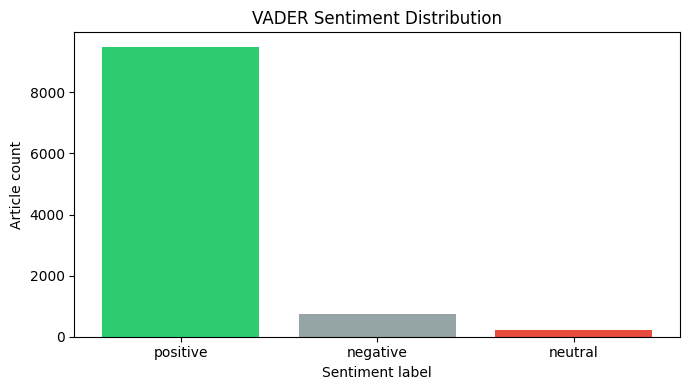

In [11]:
import matplotlib.pyplot as plt
 
print("VADER sentiment distribution:")
print(non_tech_df["vader_sentiment"].value_counts())
 
vader_dist = (
    non_tech_df["vader_sentiment"]
    .value_counts(dropna=False)
    .rename_axis("vader_sentiment")
    .reset_index(name="count")
)
vader_dist["percent"] = (vader_dist["count"] / vader_dist["count"].sum() * 100).round(2)
display(vader_dist)
 
plt.figure(figsize=(7, 4))
plt.bar(vader_dist["vader_sentiment"], vader_dist["count"], color=["#2ecc71", "#95a5a6", "#e74c3c"])
plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment label")
plt.ylabel("Article count")
plt.tight_layout()
plt.show()
 

# TextBlob

In [12]:
from textblob import TextBlob
 
def textblob_sentiment(text: str):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, "neutral"
 
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity        # range: [-1, 1]
    subjectivity = blob.sentiment.subjectivity  # range: [0, 1]
 
    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"
 
    return polarity, subjectivity, label
 
non_tech_df[["tb_polarity", "tb_subjectivity", "tb_sentiment"]] = non_tech_df["combined_text"].apply(
    lambda x: pd.Series(textblob_sentiment(x))
)

In [13]:
non_tech_df

,index,url,date,title,text,sitename,combined_text,cluster,secondary_label,secondary_score,dominant_topic,dominant_topic_prob,vader_sentiment,tb_polarity,tb_subjectivity,tb_sentiment
0,0,https://www.foxnews.com/entertainment/shazam-s...,2025-01-02,'Shazam!' star Zachary Levi compares AI to bib...,"""Shazam!"" star Zachary Levi feels a biblical d...",Fox News,'Shazam!' star Zachary Levi compares AI to bib...,6,UNSURE,0.000000,6,0.936778,positive,0.174363,0.576209,positive
1,1,https://www.foxnews.com/opinion/your-job-survi...,2025-01-02,Will your job survive Trump’s Gen AI revolution?,The Trump administration’s recent announcement...,Fox News,Will your job survive Trump’s Gen AI revolutio...,7,"discussion of AI's impact on jobs, employment,...",0.881663,5,0.459307,positive,0.168394,0.572156,positive
2,3,https://www.foxnews.com/tech/fbis-new-warning-...,2025-01-06,FBI's new warning about AI-driven scams that a...,The FBI is issuing a warning that criminals ar...,Fox News,FBI's new warning about AI-driven scams that a...,3,UNSURE,0.000000,2,0.468741,positive,0.138737,0.477821,positive
3,4,https://www.foxnews.com/tech/top-tech-stealing...,2025-01-07,Top tech stealing the show at CES 2025,Get ready for some pretty cool innovations tha...,Fox News,Top tech stealing the show at CES 2025 Get rea...,0,UNSURE,0.000000,6,0.639885,positive,0.203559,0.534053,positive
4,5,https://abcnews.go.com/Technology/wireStory/is...,2025-01-08,An Israeli TV reporter lost his ability to spe...,An Israeli TV reporter lost his ability to spe...,ABC News,An Israeli TV reporter lost his ability to spe...,6,discussion of how AI is portrayed in media or ...,0.783723,6,0.801472,negative,0.095674,0.504321,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10452,15010,https://www.forbes.com/sites/tomtaulli/2021/06...,2021-06-19T01:33:06Z,Biden’s AI Initiative: Will It Work?,The Biden administration has recently set into...,Forbes,Biden’s AI Initiative: Will It Work? The Biden...,0,"discussion of legal, regulatory, or policy iss...",0.863705,7,0.507426,positive,0.056527,0.509303,positive
10453,15011,https://www.forbes.com/sites/markminevich/2021...,2021-06-20T00:28:10Z,AI Centers Of Excellence Accelerate AI Industr...,The AI and Digital age has accelerated the rat...,Forbes,AI Centers Of Excellence Accelerate AI Industr...,9,UNSURE,0.000000,5,0.542576,positive,0.081630,0.429910,positive
10454,15012,https://www.forbes.com/sites/robtoews/2021/06/...,2021-06-20T23:24:21Z,These Are The Startups Applying AI To Tackle C...,Climate change is the most pressing threat tha...,Forbes,These Are The Startups Applying AI To Tackle C...,9,discussion of the environmental impact or ener...,0.772991,3,0.550335,positive,0.112078,0.466987,positive
10455,15014,https://www.forbes.com/sites/lanceeliot/2021/0...,2021-06-21T16:08:14Z,Whether Bicycle Riders Will Still Get Conked B...,This happens in real life.\r\nA bike rider was...,Forbes,Whether Bicycle Riders Will Still Get Conked B...,6,"discussion of legal, regulatory, or policy iss...",0.538743,6,0.593666,neutral,0.076732,0.512557,positive


TextBlob sentiment distribution:
tb_sentiment
positive    9181
neutral     1221
negative      55
Name: count, dtype: int64


,tb_sentiment,count,percent
0,positive,9181,87.80
1,neutral,1221,11.68
2,negative,55,0.53


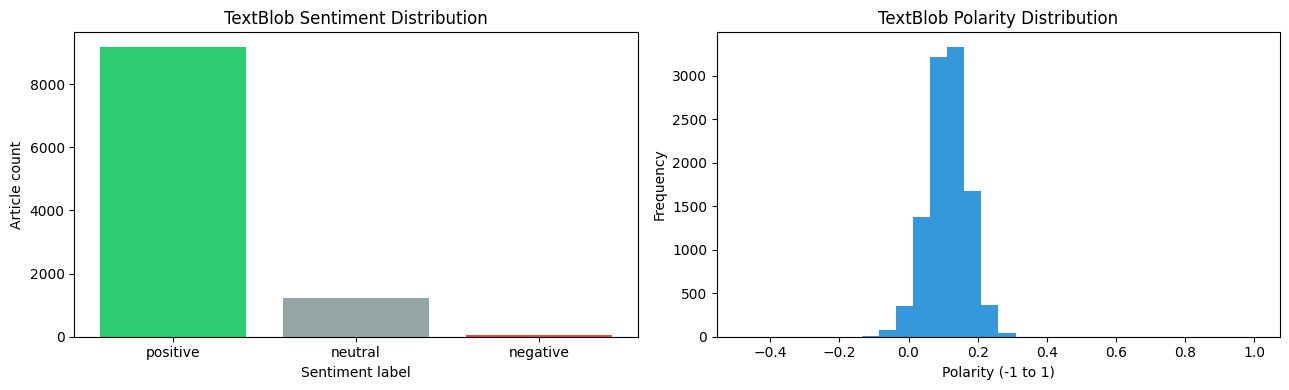

In [14]:
print("TextBlob sentiment distribution:")
print(non_tech_df["tb_sentiment"].value_counts())
 
textblob_dist = (
    non_tech_df["tb_sentiment"]
    .value_counts(dropna=False)
    .rename_axis("tb_sentiment")
    .reset_index(name="count")
)
textblob_dist["percent"] = (textblob_dist["count"] / textblob_dist["count"].sum() * 100).round(2)
display(textblob_dist)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
 
ax1.bar(textblob_dist["tb_sentiment"], textblob_dist["count"], color=["#2ecc71", "#95a5a6", "#e74c3c"])
ax1.set_title("TextBlob Sentiment Distribution")
ax1.set_xlabel("Sentiment label")
ax1.set_ylabel("Article count")
 
ax2.hist(non_tech_df["tb_polarity"].dropna(), bins=30, color="#3498db")
ax2.set_title("TextBlob Polarity Distribution")
ax2.set_xlabel("Polarity (-1 to 1)")
ax2.set_ylabel("Frequency")
 
plt.tight_layout()
plt.show()

# RoBERTa

In [15]:
from transformers import pipeline, AutoTokenizer, AutoConfig
 
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)
 
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL,
    tokenizer=tokenizer,
    truncation=True,
    max_length=512,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
def roberta_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return None, None
 
    words = text.split()
    chunks = [" ".join(words[i:i+CHUNK_WORDS]) for i in range(0, len(words), CHUNK_WORDS)]
 
    scores = {"positive": 0.0, "neutral": 0.0, "negative": 0.0}
    for chunk in chunks:
        result = sentiment_pipeline(chunk)[0]
        label = result["label"].lower()
        scores[label] += result["score"]
 
    # Average across chunks
    total = sum(scores.values())
    for k in scores:
        scores[k] /= total
 
    top_label = max(scores, key=scores.get)
    return top_label, scores
 
non_tech_df[["roberta_label", "roberta_scores"]] = non_tech_df["combined_text"].apply(
    lambda x: pd.Series(roberta_sentiment(x))
)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


RoBERTa sentiment distribution:
roberta_label
neutral     8216
positive    1974
negative     267
Name: count, dtype: int64


,roberta_label,count,percent
0,neutral,8216,78.57
1,positive,1974,18.88
2,negative,267,2.55


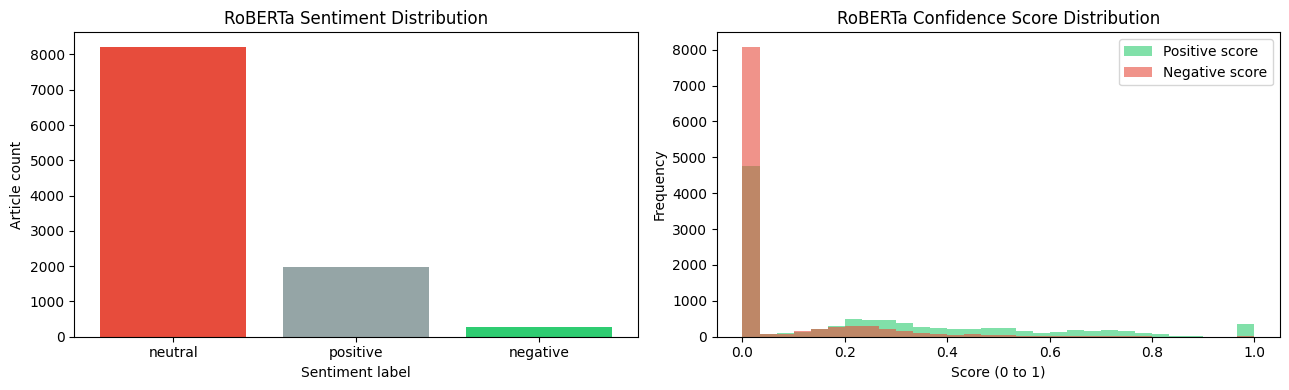

In [17]:
print("RoBERTa sentiment distribution:")
print(non_tech_df["roberta_label"].value_counts())
 
roberta_dist = (
    non_tech_df["roberta_label"]
    .value_counts(dropna=False)
    .rename_axis("roberta_label")
    .reset_index(name="count")
)
roberta_dist["percent"] = (roberta_dist["count"] / roberta_dist["count"].sum() * 100).round(2)
display(roberta_dist)
 
# Extract per-label confidence scores for histogram
non_tech_df["roberta_pos_score"] = non_tech_df["roberta_scores"].apply(
    lambda x: x["positive"] if isinstance(x, dict) else None
)
non_tech_df["roberta_neg_score"] = non_tech_df["roberta_scores"].apply(
    lambda x: x["negative"] if isinstance(x, dict) else None
)
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
 
ax1.bar(roberta_dist["roberta_label"], roberta_dist["count"], color=["#e74c3c", "#95a5a6", "#2ecc71"])
ax1.set_title("RoBERTa Sentiment Distribution")
ax1.set_xlabel("Sentiment label")
ax1.set_ylabel("Article count")
 
ax2.hist(non_tech_df["roberta_pos_score"].dropna(), bins=30, alpha=0.6, label="Positive score", color="#2ecc71")
ax2.hist(non_tech_df["roberta_neg_score"].dropna(), bins=30, alpha=0.6, label="Negative score", color="#e74c3c")
ax2.set_title("RoBERTa Confidence Score Distribution")
ax2.set_xlabel("Score (0 to 1)")
ax2.set_ylabel("Frequency")
ax2.legend()
 
plt.tight_layout()
plt.show()

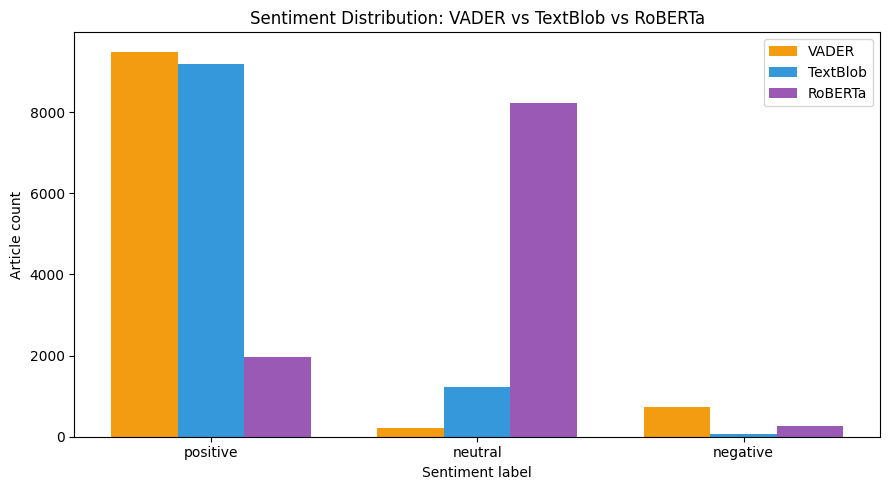

RoBERTa vs VADER agreement:    21.8%
RoBERTa vs TextBlob agreement: 29.0%


In [18]:
labels = ["positive", "neutral", "negative"]
vader_counts   = [non_tech_df["vader_sentiment"].value_counts().get(l, 0) for l in labels]
tb_counts      = [non_tech_df["tb_sentiment"].value_counts().get(l, 0) for l in labels]
roberta_counts = [non_tech_df["roberta_label"].value_counts().get(l, 0) for l in labels]
 
x = np.arange(len(labels))
width = 0.25
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, vader_counts,   width, label="VADER",    color="#f39c12")
ax.bar(x,         tb_counts,      width, label="TextBlob", color="#3498db")
ax.bar(x + width, roberta_counts, width, label="RoBERTa",  color="#9b59b6")
 
ax.set_title("Sentiment Distribution: VADER vs TextBlob vs RoBERTa")
ax.set_xlabel("Sentiment label")
ax.set_ylabel("Article count")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()
 
# Agreement rate between RoBERTa and VADER
agreement_vader   = (non_tech_df["roberta_label"] == non_tech_df["vader_sentiment"]).mean()
agreement_tb      = (non_tech_df["roberta_label"] == non_tech_df["tb_sentiment"]).mean()
print(f"RoBERTa vs VADER agreement:    {agreement_vader:.1%}")
print(f"RoBERTa vs TextBlob agreement: {agreement_tb:.1%}")

In [19]:
# Serialize dict column to JSON string before writing to SQLite
non_tech_df["roberta_scores"] = non_tech_df["roberta_scores"].apply(
    lambda x: json.dumps(x) if isinstance(x, dict) else None
)

conn = sqlite3.connect("/content/drive/MyDrive/CAP5771-abbhinav.sriram/dev_notebooks/db.sqlite")
non_tech_df.to_sql("modified_articles", conn, if_exists="replace", index=False)
conn.close()